In [1]:
print("hi")

hi


In [ ]:

from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI

In [3]:
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
import os
load_dotenv(override=True)

True

In [5]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        model_kwargs={"temperature":0.7},
        max_tokens= 1000
    )

In [6]:
llm=get_groq_llm()

d:\Agent_From_Scratch\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [7]:
class LLMState(TypedDict):
    question:str
    answer:str

In [8]:
def chat_llm(state:LLMState):
    question=state['question']

    ##prompt:
    prompt=f"Answer the following question {question}"
    answer=llm.invoke(prompt).content

    state['answer']=answer

    return state
    

In [9]:
graph=StateGraph(LLMState)

##add nodes

graph.add_node("chat_llm",chat_llm)

In [10]:
##add edge 

graph.add_edge(START,"chat_llm")
graph.add_edge("chat_llm",END)

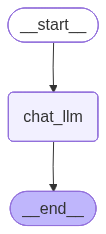

In [11]:
workflow=graph.compile() 

workflow

In [13]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state['answer'])

The Moon doesn’t keep a single fixed distance from Earth—it orbits in an ellipse—so its distance varies over the course of each month.  

| Position | Approximate distance from Earth |
|----------|---------------------------------|
| **Average (mean) distance** | **≈ 384,400 km** (≈ 238,900 mi) |
| **Perigee** (closest point) | ≈ 356,500 km (≈ 221,500 mi) |
| **Apogee** (farthest point) | ≈ 406,700 km (≈ 252,700 mi) |

**Key points**

- The average distance (384 400 km) is often quoted as “the distance to the Moon.”
- Because the Moon’s orbit is slightly eccentric (eccentricity ≈ 0.055), the distance swings by about ±5 % around that average.
- The Moon completes an orbit roughly every 27.3 days (sidereal period) and a full cycle of phases every 29.5 days (synodic period), so the perigee‑apogee variation repeats on a roughly monthly basis.
- Light from the Moon takes about **1.28 seconds** to reach Earth at the average distance.

So, if you need a single figure, use **≈ 384 400 km (≈ 23

In [17]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [16]:
print(final_state['answer'])


The average distance from the Sun to the Earth is about **1 Astronomical Unit (AU)**, which is:

- **≈ 149.6 million kilometres (km)**
- **≈ 93 million miles (mi)**  

Because Earth’s orbit is slightly elliptical, the actual distance varies over the year:

| Position in orbit | Distance from Sun |
|-------------------|-------------------|
| **Perihelion** (closest, early January) | ~147.1 million km (≈ 91.4 million mi) |
| **Aphelion** (farthest, early July)   | ~152.1 million km (≈ 94.5 million mi) |

If you were asking about a different object (e.g., another planet, a spacecraft, or a specific location in the solar system), just let me know and I can give the corresponding distance.


In [ ]:
##Call to llm
##Stateless Calls :It does not have any previous message history